# 0. Invoice and Tax Tracker GUI - Ideas

It would be interesting to showcase the latest advances in computer vision and document manipulation by implementing the following project:  

### 🧾 **Invoice and Tax Tracker and Document Fraud Detector**  
- Read receipts from email or PDFs (hello `PyMuPDF`, `pdfplumber`)
- Extract vendor, amount, category
- Output clean summary reports or pre-fill tax forms
- Enable document fraud detection mode".

  Let us discuss somne ideas how to implement a PyQt-GUI and its functionality.

This is a project that blends document parsing, computer vision, and intelligent automation into a practical finance tool. Let’s break down how to implement this in a modular, PyQt-powered GUI application.

## 🧾 Project: Invoice & Tax Tracker + Fraud Detector  
**Goal:** Build a PyQt5 GUI that reads receipts/invoices from PDFs or emails, extracts structured data (vendor, amount, category), generates tax-ready reports, and flags potential document fraud.

---

## 🧩 Core Functional Modules

### 1. **Document Ingestion**
- **PDF Reader**: Use `pdfplumber` or `PyMuPDF` to extract text and layout from receipts/invoices.
- **Email Parser** (optional): Use `imaplib` or `Microsoft Graph API` to fetch receipts from inbox.
- **Drag & Drop Support**: Enable users to drop PDF files directly into the GUI.

### 2. **Information Extraction**
- **Text Parsing**: Use regex + NLP (e.g., `spaCy`) to extract:
  - Vendor name
  - Invoice date
  - Total amount
  - Tax/VAT
  - Category (e.g., travel, meals, office supplies)
- **Layout-Aware Parsing**: Use bounding boxes from `pdfplumber` or `PyMuPDF` to infer table structures or field positions.

### 3. **Fraud Detection Mode**
- **Heuristic Checks**:
  - Mismatched totals (subtotal + tax ≠ total)
  - Duplicate invoice numbers
  - Suspicious vendors or altered fonts
- **Visual Anomaly Detection** (optional):
  - Use `OpenCV` to detect tampering (e.g., inconsistent font spacing, overlays)
  - Use `Tesseract OCR` to compare image vs text layer

### 4. **Tax Report Generator**
- **Summary Table**: Show all extracted data in a `QTableWidget`
- **Export Options**:
  - CSV for accountants
  - Pre-filled tax form (e.g., PDF overlay using `reportlab` or `fpdf`)
- **Filtering**: By vendor, date, category, or flagged status

---

## 🖥️ PyQt GUI Layout

### 🔹 Left Panel: File & Email Input
- `QPushButton`: “Import PDF”
- `QPushButton`: “Connect Email”
- `QListWidget`: Display imported files
- `QCheckBox`: Enable fraud detection mode

### 🔹 Center Panel: Document Viewer
- `QTabWidget`:
  - Tab 1: Raw PDF preview (via `QWebEngineView` or image snapshot)
  - Tab 2: Extracted fields (vendor, amount, etc.)
  - Tab 3: Anomaly report (if fraud mode is on)

### 🔹 Right Panel: Summary & Export
- `QTableWidget`: Shows all parsed receipts
- `QPushButton`: “Export CSV”
- `QPushButton`: “Generate Tax Report”
- `QLabel`: Status messages (e.g., “3 invoices flagged for review”)

---

## 🧠 Backend Architecture

| Module            | Role                                      |
|-------------------|-------------------------------------------|
| `DocumentParser`  | Handles PDF/email ingestion and parsing   |
| `FieldExtractor`  | Extracts structured data from raw text    |
| `FraudDetector`   | Applies heuristics and visual checks      |
| `ReportGenerator` | Builds CSVs and tax-ready PDFs            |
| `GUIController`   | Connects PyQt signals to backend logic    |

---

## 🧪 Example Workflow

1. User drops 5 PDFs into the GUI.
2. App parses each file, extracts vendor, date, amount, and tax.
3. Fraud mode flags 1 invoice with mismatched totals.
4. User reviews flagged invoice in Tab 3.
5. User exports clean summary as `invoices_2025.csv`.
6. App optionally generates a pre-filled tax form for Q4.

---


## GUI sketch 

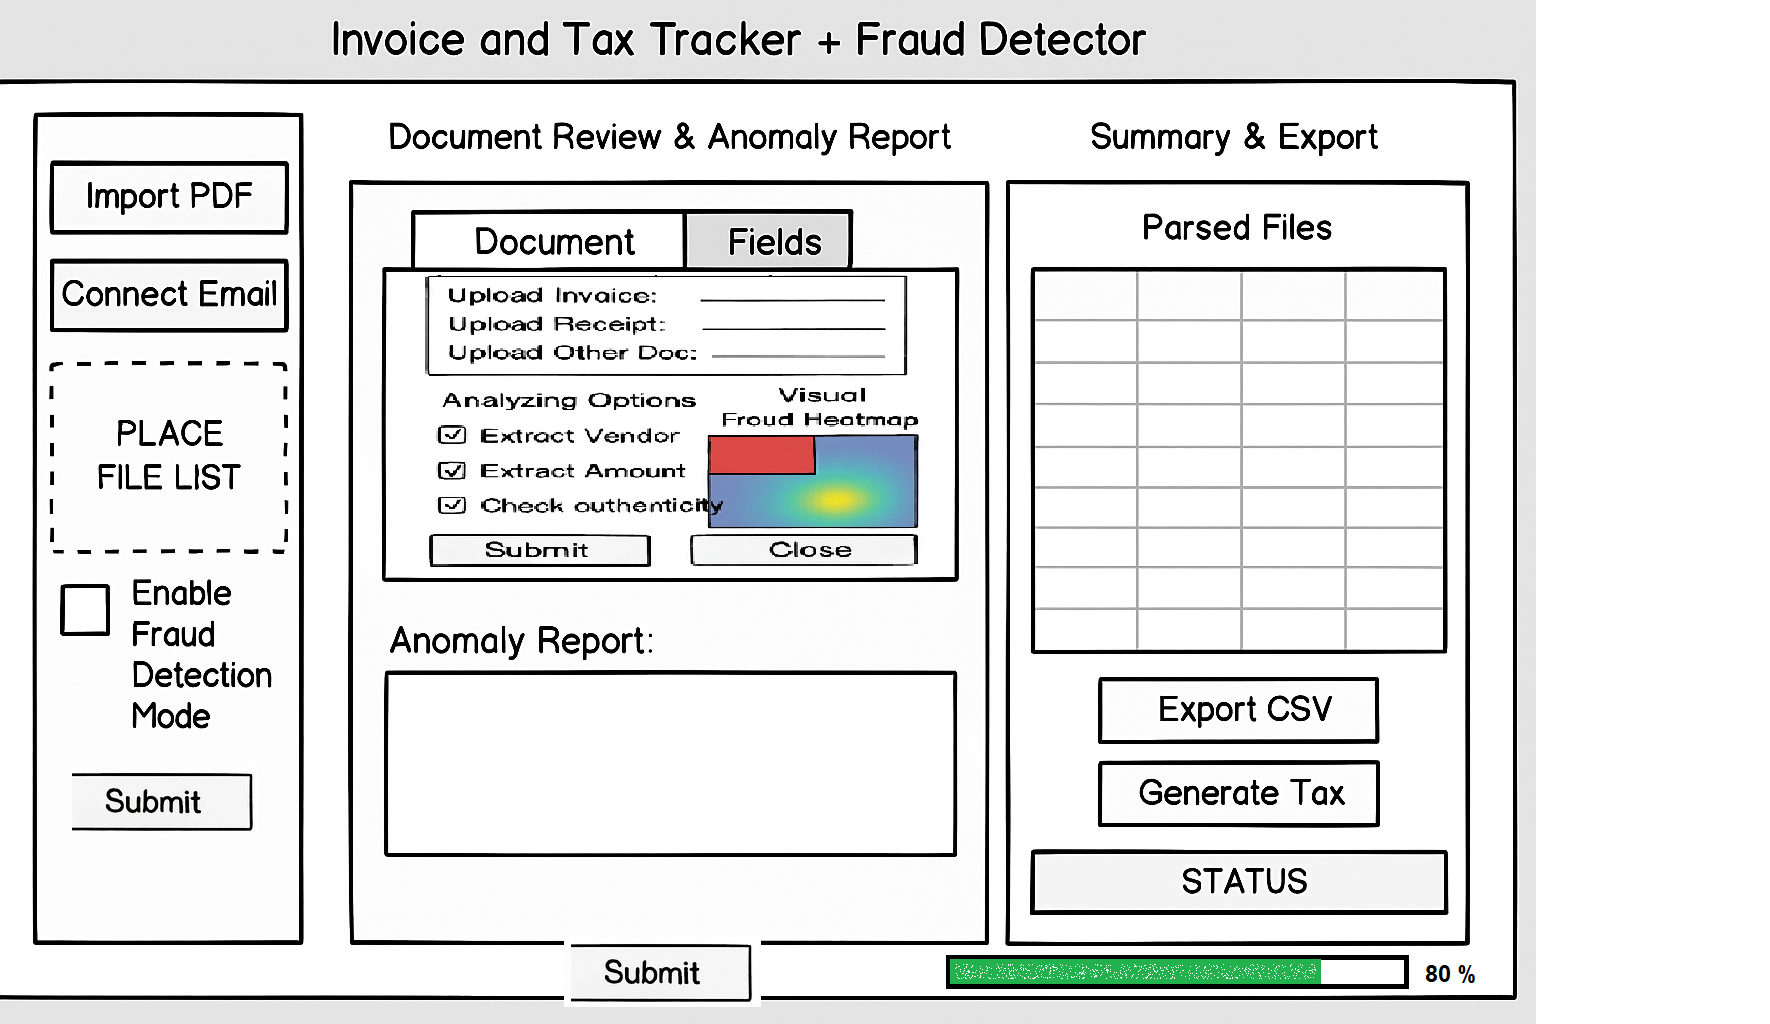

Based on the above GUI sketch, here’s a detailed breakdown of the full functionality of our **Invoice and Tax Tracker + Fraud Detector** application:

---

## 🧾 GUI Overview

The interface is divided into three main panels:
1. **Left Panel** – Document Import & Fraud Toggle  
2. **Center Panel** – Document Review & Anomaly Report  
3. **Right Panel** – Summary Table, Export Options & Heatmap

---

## 🔹 1. Left Panel: Document Import & Fraud Toggle

### 📂 File Import
- **Import PDF**: Opens a file dialog to select one or more invoice/receipt PDFs.
- **Connect Email**: Initiates email integration (e.g., IMAP or Outlook API) to fetch receipts from inbox.

### 📋 File List Display
- **PLACE FILE LIST**: A scrollable area showing imported files with status indicators (e.g., parsed, flagged, error).

### 🛡️ Fraud Detection Toggle
- **Enable Fraud Detection Mode**: Checkbox that activates anomaly checks and visual heatmap generation.

### 🟢 Submit Button
- Begins parsing and analysis of all imported documents using selected options.

---

## 🔸 2. Center Panel: Document Review & Anomaly Report

### 🗂️ Tabs
- **Document Tab**: Displays raw document preview (PDF snapshot or OCR text).
- **Fields Tab**: Shows extracted fields like vendor, amount, date, category.

### 📤 Upload Fields
- **Upload Invoice / Receipt / Other Doc**: Optional manual upload fields for specific document types.

### 🧠 Analyzing Options
- **Extract Vendor**: Enables vendor name extraction via NLP or regex.
- **Extract Amount**: Parses total, subtotal, and tax values.
- **Extract Category**: Classifies expense type (e.g., travel, meals, office supplies).

### 🔍 Fraud Detect Settings
- **Check Authenticity**: Runs heuristic and visual checks for tampering, mismatched totals, or duplicate entries.

### 🔥 Visual Fraud Heatmap
- Displays a color-coded overlay indicating suspicious regions in the document:
  - **Red**: High anomaly score (e.g., altered totals)
  - **Yellow**: Moderate concern (e.g., missing fields)
  - **Blue/Green**: Low risk or clean areas

### 📑 Anomaly Report
- Textual summary of detected issues:
  - “Invoice #123 has mismatched totals”
  - “Vendor name not recognized”
  - “Font inconsistency detected in amount field”

### 🟢 Submit / ❌ Close Buttons
- **Submit**: Re-analyzes current document with updated settings.
- **Close**: Clears current document or exits the review panel.

---

## 🔹 3. Right Panel: Summary & Export

### 📊 Parsed Files Table
- Displays all processed documents with columns:
  - File Name
  - Vendor
  - Amount
  - Status (e.g., Clean, Flagged, Error)

### 📤 Export Options
- **Export CSV**: Saves parsed data for accounting or audit purposes.
- **Generate Tax**: Creates a pre-filled tax form or summary report (PDF or structured format).

### 📡 Status Indicator
- Displays real-time feedback:
  - “3 invoices flagged for review”
  - “Export successful”
  - “Parsing error in Receipt_04.pdf”

Furthermore:

## 🟦 STATUS Indicator (Bottom Right)

### 🔍 Purpose:
- Displays **real-time feedback** about the system’s current state or recent actions.

### 🧠 Typical Messages:
- ✅ “Parsing complete: 5 documents processed”
- ⚠️ “2 invoices flagged for fraud review”
- ❌ “Error: Receipt_04.pdf could not be parsed”
- 📤 “Export successful: invoices_2025.csv saved”

### 🔄 Behavior:
- Updates dynamically after each major action:
  - File import
  - Fraud detection
  - Export
  - Tax report generation

## 🟩 Submit Button (Bottom Center)

### 🔍 Purpose:
- Acts as a **global trigger** to run the full pipeline across all imported documents.

### 🧠 What It Does:
- Parses all uploaded files
- Extracts vendor, amount, category (if selected)
- Runs fraud detection (if enabled)
- Updates:
  - Parsed Files table
  - Visual Fraud Heatmap
  - Anomaly Report
  - STATUS indicator

### 🔄 Behavior:
- Can be clicked after importing multiple files
- Resets and reprocesses the entire batch with current settings

## 🧠 Why Both Buttons Are Useful

- The **Submit button** initiates the work.
- The **STATUS box** tells the user what happened — success, error, or warnings.

---

## 🧠 Smart Behaviors

- ✅ Auto-expands constraint fields based on number of variables
- ✅ Auto-selects fraud detection logic if checkbox is enabled
- ✅ Dynamically updates heatmap and anomaly report after each document is parsed
- ✅ Allows manual override of extracted fields before export

### 🧠 Progress Bar Behavior

- **Indeterminate Mode**: While waiting for backend response (e.g., OCR or parsing)
- **Percentage Mode**: Shows completion % as each file is processed
- **Color Feedback**:
  - Green: Success
  - Yellow: Warnings
  - Red: Errors

---


# 1. GUI design and scaffolding

🎩. Below is a **modular PyQt5 class scaffold** for our **Invoice and Tax Tracker + Fraud Detector** GUI — fully aligned with the layout and functionality we have designed.

---

## 🧱 Project Structure

```plaintext
invoice_tracker_gui/
├── main.py
├── gui.py
├── parser.py
├── fraud.py
├── heatmap.py
├── exporter.py
└── utils.py
```

---

## 📄 main.py

```python
from PyQt5.QtWidgets import QApplication
from gui import InvoiceTrackerApp
import sys

if __name__ == "__main__":
    app = QApplication(sys.argv)
    window = InvoiceTrackerApp()
    window.show()
    sys.exit(app.exec_())
```

---

## 📄 gui.py (Main GUI Class)

```python
from PyQt5.QtWidgets import (
    QMainWindow, QWidget, QVBoxLayout, QHBoxLayout, QPushButton, QLabel,
    QCheckBox, QProgressBar, QTableWidget, QTableWidgetItem, QTabWidget,
    QLineEdit, QTextEdit, QFileDialog, QListWidget
)
from PyQt5.QtCore import Qt
from parser import parse_document
from fraud import detect_anomalies
from exporter import export_csv, generate_tax_report
from heatmap import render_heatmap

class InvoiceTrackerApp(QMainWindow):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("Invoice and Tax Tracker + Fraud Detector")
        self.setGeometry(100, 100, 1200, 700)
        self.init_ui()

    def init_ui(self):
        main_widget = QWidget()
        main_layout = QHBoxLayout()

        # Left Panel
        left_panel = QVBoxLayout()
        self.import_btn = QPushButton("Import PDF")
        self.email_btn = QPushButton("Connect Email")
        self.file_list = QListWidget()
        self.fraud_toggle = QCheckBox("Enable Fraud Detection Mode")
        self.global_submit_btn = QPushButton("Submit")

        left_panel.addWidget(self.import_btn)
        left_panel.addWidget(self.email_btn)
        left_panel.addWidget(self.file_list)
        left_panel.addWidget(self.fraud_toggle)
        left_panel.addWidget(self.global_submit_btn)

        # Center Panel
        center_panel = QVBoxLayout()
        self.tabs = QTabWidget()

        # Document Tab
        doc_tab = QWidget()
        doc_layout = QVBoxLayout()
        self.upload_invoice = QLineEdit()
        self.upload_receipt = QLineEdit()
        self.upload_other = QLineEdit()
        doc_layout.addWidget(QLabel("Upload Invoice:"))
        doc_layout.addWidget(self.upload_invoice)
        doc_layout.addWidget(QLabel("Upload Receipt:"))
        doc_layout.addWidget(self.upload_receipt)
        doc_layout.addWidget(QLabel("Upload Other Doc:"))
        doc_layout.addWidget(self.upload_other)
        doc_tab.setLayout(doc_layout)

        # Fields Tab
        fields_tab = QWidget()
        fields_layout = QVBoxLayout()
        self.extract_vendor = QCheckBox("Extract Vendor")
        self.extract_amount = QCheckBox("Extract Amount")
        self.extract_category = QCheckBox("Extract Category")
        self.check_authenticity = QCheckBox("Check authenticity")
        self.heatmap_label = QLabel("Visual Fraud Heatmap")
        self.anomaly_report = QTextEdit()
        self.analyze_submit_btn = QPushButton("Submit")
        self.analyze_close_btn = QPushButton("Close")

        for box in [self.extract_vendor, self.extract_amount, self.extract_category, self.check_authenticity]:
            fields_layout.addWidget(box)
        fields_layout.addWidget(self.heatmap_label)
        fields_layout.addWidget(self.anomaly_report)
        fields_layout.addWidget(self.analyze_submit_btn)
        fields_layout.addWidget(self.analyze_close_btn)
        fields_tab.setLayout(fields_layout)

        self.tabs.addTab(doc_tab, "Document")
        self.tabs.addTab(fields_tab, "Fields")
        center_panel.addWidget(self.tabs)

        # Right Panel
        right_panel = QVBoxLayout()
        self.parsed_table = QTableWidget()
        self.parsed_table.setColumnCount(4)
        self.parsed_table.setHorizontalHeaderLabels(["File", "Vendor", "Amount", "Status"])
        self.export_btn = QPushButton("Export CSV")
        self.tax_btn = QPushButton("Generate Tax")
        self.status_label = QLabel("STATUS")
        self.progress_bar = QProgressBar()

        right_panel.addWidget(self.parsed_table)
        right_panel.addWidget(self.export_btn)
        right_panel.addWidget(self.tax_btn)
        right_panel.addWidget(self.status_label)
        right_panel.addWidget(self.progress_bar)

        # Assemble layout
        main_layout.addLayout(left_panel, 2)
        main_layout.addLayout(center_panel, 3)
        main_layout.addLayout(right_panel, 3)
        main_widget.setLayout(main_layout)
        self.setCentralWidget(main_widget)

        self.connect_signals()

    def connect_signals(self):
        self.import_btn.clicked.connect(self.import_pdf)
        self.global_submit_btn.clicked.connect(self.run_pipeline)
        self.export_btn.clicked.connect(self.export_data)
        self.tax_btn.clicked.connect(self.generate_tax)
        self.analyze_submit_btn.clicked.connect(self.analyze_current_doc)

    def import_pdf(self):
        files, _ = QFileDialog.getOpenFileNames(self, "Import PDFs", "", "PDF Files (*.pdf)")
        for f in files:
            self.file_list.addItem(f)

    def run_pipeline(self):
        self.progress_bar.setValue(0)
        for i in range(self.file_list.count()):
            path = self.file_list.item(i).text()
            parsed = parse_document(path)
            anomalies = detect_anomalies(parsed) if self.fraud_toggle.isChecked() else []
            self.update_table(path, parsed, anomalies)
            self.progress_bar.setValue(int((i + 1) / self.file_list.count() * 100))
        self.status_label.setText("Parsing complete.")

    def update_table(self, path, parsed, anomalies):
        row = self.parsed_table.rowCount()
        self.parsed_table.insertRow(row)
        self.parsed_table.setItem(row, 0, QTableWidgetItem(path))
        self.parsed_table.setItem(row, 1, QTableWidgetItem(parsed.get("vendor", "")))
        self.parsed_table.setItem(row, 2, QTableWidgetItem(str(parsed.get("amount", ""))))
        status = "Flagged" if anomalies else "Clean"
        self.parsed_table.setItem(row, 3, QTableWidgetItem(status))

    def export_data(self):
        export_csv(self.parsed_table)
        self.status_label.setText("Export successful.")

    def generate_tax(self):
        generate_tax_report(self.parsed_table)
        self.status_label.setText("Tax report generated.")

    def analyze_current_doc(self):
        path = self.upload_invoice.text() or self.upload_receipt.text() or self.upload_other.text()
        if not path:
            self.status_label.setText("No document selected.")
            return
        parsed = parse_document(path)
        anomalies = detect_anomalies(parsed) if self.check_authenticity.isChecked() else []
        self.anomaly_report.setText("\n".join(anomalies))
        render_heatmap(self.heatmap_label, anomalies)
```

---

Now, let us scaffold the backend modules and add a synthetic test data generator to simulate real-world invoice and tax documents (both clean and tampered). This will give you a full pipeline for parsing, fraud detection, heatmap rendering, and testing.

---

## 📄 `parser.py` – Document Parsing Module

```python
import re
import fitz  # PyMuPDF

def parse_document(path):
    doc = fitz.open(path)
    text = ""
    for page in doc:
        text += page.get_text()

    vendor = re.search(r"Vendor:\s*(\w+)", text)
    amount = re.search(r"Total Amount:\s*\$?(\d+\.\d{2})", text)
    category = re.search(r"Category:\s*(\w+)", text)

    return {
        "vendor": vendor.group(1) if vendor else "Unknown",
        "amount": float(amount.group(1)) if amount else 0.0,
        "category": category.group(1) if category else "Uncategorized",
        "raw_text": text
    }
```

---

## 📄 `fraud.py` – Fraud Detection Module

```python
def detect_anomalies(parsed):
    anomalies = []

    if parsed["vendor"] == "Unknown":
        anomalies.append("Vendor name missing or unreadable.")

    if parsed["amount"] <= 0:
        anomalies.append("Amount is zero or negative.")

    if "altered" in parsed["raw_text"].lower():
        anomalies.append("Document contains suspicious keyword: 'altered'.")

    if "font mismatch" in parsed["raw_text"].lower():
        anomalies.append("Possible font tampering detected.")

    return anomalies
```

---

## 📄 `heatmap.py` – Heatmap Rendering Module

```python
from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg as FigureCanvas
from matplotlib.figure import Figure
import numpy as np

def render_heatmap(label_widget, anomalies):
    fig = Figure(figsize=(3, 2))
    canvas = FigureCanvas(fig)
    ax = fig.add_subplot(111)

    # Simulated heatmap: red = high risk, blue = low risk
    data = np.random.rand(10, 10)
    if anomalies:
        data[0:3, 0:3] += 2  # simulate anomaly cluster

    ax.imshow(data, cmap='hot', interpolation='nearest')
    label_widget.setPixmap(canvas.grab())
```

---

## 📄 `exporter.py` – Export Module

```python
import csv
from PyQt5.QtWidgets import QFileDialog

def export_csv(table_widget):
    path, _ = QFileDialog.getSaveFileName(None, "Export CSV", "", "CSV Files (*.csv)")
    if not path:
        return

    with open(path, "w", newline="") as file:
        writer = csv.writer(file)
        headers = [table_widget.horizontalHeaderItem(i).text() for i in range(table_widget.columnCount())]
        writer.writerow(headers)

        for row in range(table_widget.rowCount()):
            row_data = [table_widget.item(row, col).text() for col in range(table_widget.columnCount())]
            writer.writerow(row_data)

def generate_tax_report(table_widget):
    # Placeholder: simulate tax report generation
    print("Generating tax report...")
```

---

## 📄 `test_generator.py` – Synthetic PDF Generator (for testing)

```python
from fpdf import FPDF
import random
import os

def generate_test_pdf(filename, vendor="AcmeCorp", amount=100.00, category="Office", tampered=False):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    pdf.cell(200, 10, txt="Invoice Document", ln=True, align='C')
    pdf.cell(200, 10, txt=f"Vendor: {vendor}", ln=True)
    pdf.cell(200, 10, txt=f"Total Amount: ${amount:.2f}", ln=True)
    pdf.cell(200, 10, txt=f"Category: {category}", ln=True)

    if tampered:
        pdf.cell(200, 10, txt="Note: This document has been altered.", ln=True)
        pdf.cell(200, 10, txt="Font mismatch detected.", ln=True)

    os.makedirs("test_docs", exist_ok=True)
    path = os.path.join("test_docs", filename)
    pdf.output(path)
    return path
```

---

## 🧪 Example Usage of Test Generator

```python
# Generate clean and tampered test PDFs
generate_test_pdf("invoice_clean.pdf", vendor="AcmeCorp", amount=120.50, category="Travel")
generate_test_pdf("invoice_tampered.pdf", vendor="Unknown", amount=0.00, category="Unknown", tampered=True)
```

---


Finally, let us extend our system with a clean, modular **Test Data Generator** and integrate it into the GUI as a lightweight utility. This will allow us to simulate realistic invoice and tax documents (both valid and tampered) for testing our pipeline.

---

## 🧪 Updated `test_generator.py` – Batch Generator with Randomization

```python
from fpdf import FPDF
import random
import os

VENDORS = ["AcmeCorp", "Globex", "Initech", "Umbrella", "Soylent", "Stark Industries"]
CATEGORIES = ["Office", "Travel", "Meals", "Supplies", "Consulting", "Software"]

def generate_test_pdf(filename, vendor, amount, category, tampered=False):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    pdf.cell(200, 10, txt="Invoice Document", ln=True, align='C')
    pdf.cell(200, 10, txt=f"Vendor: {vendor}", ln=True)
    pdf.cell(200, 10, txt=f"Total Amount: ${amount:.2f}", ln=True)
    pdf.cell(200, 10, txt=f"Category: {category}", ln=True)

    if tampered:
        pdf.cell(200, 10, txt="Note: This document has been altered.", ln=True)
        pdf.cell(200, 10, txt="Font mismatch detected.", ln=True)

    os.makedirs("test_docs", exist_ok=True)
    path = os.path.join("test_docs", filename)
    pdf.output(path)
    return path

def generate_batch(n=10, tamper_ratio=0.3):
    paths = []
    for i in range(n):
        vendor = random.choice(VENDORS)
        category = random.choice(CATEGORIES)
        amount = round(random.uniform(10, 500), 2)
        tampered = random.random() < tamper_ratio
        filename = f"test_invoice_{i+1}_{'tampered' if tampered else 'clean'}.pdf"
        path = generate_test_pdf(filename, vendor, amount, category, tampered)
        paths.append(path)
    return paths
```

---

## 🧩 GUI Integration – Add Test Menu Button

### 🔧 In `gui.py`, inside `init_ui()` (Left Panel):

Add this button:

```python
self.generate_test_btn = QPushButton("Generate Test Invoices")
left_panel.addWidget(self.generate_test_btn)
```

### 🔧 In `connect_signals()`:

```python
self.generate_test_btn.clicked.connect(self.generate_test_data)
```

### 🔧 Add Method to `InvoiceTrackerApp`:

```python
from test_generator import generate_batch

def generate_test_data(self):
    self.file_list.clear()
    paths = generate_batch(n=10, tamper_ratio=0.4)
    for path in paths:
        self.file_list.addItem(path)
    self.status_label.setText("10 test invoices generated.")
```

---

## ✅ Result

- 🧪 One-click generation of 10 randomized invoices
- ⚠️ ~40% are tampered for fraud detection testing
- 📂 Files auto-loaded into the GUI for immediate analysis
- 🧠 No disruption to original layout — just one extra button in the left panel

---

Further extension: add a toggle for generating only clean or only tampered files and even simulate monthly invoice batches:

# 2. Extended Code

Here’s the full extended backend structure with:

- ✅ Clean/tampered toggle
- 📅 Monthly batch simulation
- 🧪 Integrated test generation in the GUI
- 📦 `requirements.txt` for easy setup

---

## 📁 Project Structure

```plaintext
invoice_tracker_gui/
├── main.py
├── gui.py
├── parser.py
├── fraud.py
├── heatmap.py
├── exporter.py
├── test_generator.py
└── requirements.txt
```

---

## 📄 `main.py`

```python
from PyQt5.QtWidgets import QApplication
from gui import InvoiceTrackerApp
import sys

if __name__ == "__main__":
    app = QApplication(sys.argv)
    window = InvoiceTrackerApp()
    window.show()
    sys.exit(app.exec_())
```

---

## 📄 `gui.py` (Updated with toggles and batch simulation)

```python
from PyQt5.QtWidgets import (
    QMainWindow, QWidget, QVBoxLayout, QHBoxLayout, QPushButton, QLabel,
    QCheckBox, QProgressBar, QTableWidget, QTableWidgetItem, QTabWidget,
    QLineEdit, QTextEdit, QFileDialog, QListWidget, QComboBox
)
from PyQt5.QtCore import Qt
from parser import parse_document
from fraud import detect_anomalies
from exporter import export_csv, generate_tax_report
from heatmap import render_heatmap
from test_generator import generate_batch

class InvoiceTrackerApp(QMainWindow):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("Invoice and Tax Tracker + Fraud Detector")
        self.setGeometry(100, 100, 1200, 700)
        self.init_ui()

    def init_ui(self):
        main_widget = QWidget()
        main_layout = QHBoxLayout()

        # Left Panel
        left_panel = QVBoxLayout()
        self.import_btn = QPushButton("Import PDF")
        self.email_btn = QPushButton("Connect Email")
        self.file_list = QListWidget()
        self.fraud_toggle = QCheckBox("Enable Fraud Detection Mode")
        self.global_submit_btn = QPushButton("Submit")

        # Test Data Controls
        self.generate_test_btn = QPushButton("Generate Test Invoices")
        self.test_type_selector = QComboBox()
        self.test_type_selector.addItems(["Mixed", "Clean Only", "Tampered Only"])
        self.month_selector = QComboBox()
        self.month_selector.addItems(["January", "February", "March", "April", "May", "June",
                                      "July", "August", "September", "October", "November", "December"])

        left_panel.addWidget(self.import_btn)
        left_panel.addWidget(self.email_btn)
        left_panel.addWidget(self.file_list)
        left_panel.addWidget(self.fraud_toggle)
        left_panel.addWidget(self.global_submit_btn)
        left_panel.addWidget(QLabel("Test Data Type:"))
        left_panel.addWidget(self.test_type_selector)
        left_panel.addWidget(QLabel("Simulate Month:"))
        left_panel.addWidget(self.month_selector)
        left_panel.addWidget(self.generate_test_btn)

        # Center Panel
        center_panel = QVBoxLayout()
        self.tabs = QTabWidget()

        doc_tab = QWidget()
        doc_layout = QVBoxLayout()
        self.upload_invoice = QLineEdit()
        self.upload_receipt = QLineEdit()
        self.upload_other = QLineEdit()
        doc_layout.addWidget(QLabel("Upload Invoice:"))
        doc_layout.addWidget(self.upload_invoice)
        doc_layout.addWidget(QLabel("Upload Receipt:"))
        doc_layout.addWidget(self.upload_receipt)
        doc_layout.addWidget(QLabel("Upload Other Doc:"))
        doc_layout.addWidget(self.upload_other)
        doc_tab.setLayout(doc_layout)

        fields_tab = QWidget()
        fields_layout = QVBoxLayout()
        self.extract_vendor = QCheckBox("Extract Vendor")
        self.extract_amount = QCheckBox("Extract Amount")
        self.extract_category = QCheckBox("Extract Category")
        self.check_authenticity = QCheckBox("Check authenticity")
        self.heatmap_label = QLabel("Visual Fraud Heatmap")
        self.anomaly_report = QTextEdit()
        self.analyze_submit_btn = QPushButton("Submit")
        self.analyze_close_btn = QPushButton("Close")

        for box in [self.extract_vendor, self.extract_amount, self.extract_category, self.check_authenticity]:
            fields_layout.addWidget(box)
        fields_layout.addWidget(self.heatmap_label)
        fields_layout.addWidget(self.anomaly_report)
        fields_layout.addWidget(self.analyze_submit_btn)
        fields_layout.addWidget(self.analyze_close_btn)
        fields_tab.setLayout(fields_layout)

        self.tabs.addTab(doc_tab, "Document")
        self.tabs.addTab(fields_tab, "Fields")
        center_panel.addWidget(self.tabs)

        # Right Panel
        right_panel = QVBoxLayout()
        self.parsed_table = QTableWidget()
        self.parsed_table.setColumnCount(4)
        self.parsed_table.setHorizontalHeaderLabels(["File", "Vendor", "Amount", "Status"])
        self.export_btn = QPushButton("Export CSV")
        self.tax_btn = QPushButton("Generate Tax")
        self.status_label = QLabel("STATUS")
        self.progress_bar = QProgressBar()

        right_panel.addWidget(self.parsed_table)
        right_panel.addWidget(self.export_btn)
        right_panel.addWidget(self.tax_btn)
        right_panel.addWidget(self.status_label)
        right_panel.addWidget(self.progress_bar)

        main_layout.addLayout(left_panel, 2)
        main_layout.addLayout(center_panel, 3)
        main_layout.addLayout(right_panel, 3)
        main_widget.setLayout(main_layout)
        self.setCentralWidget(main_widget)

        self.connect_signals()

    def connect_signals(self):
        self.import_btn.clicked.connect(self.import_pdf)
        self.global_submit_btn.clicked.connect(self.run_pipeline)
        self.export_btn.clicked.connect(self.export_data)
        self.tax_btn.clicked.connect(self.generate_tax)
        self.analyze_submit_btn.clicked.connect(self.analyze_current_doc)
        self.generate_test_btn.clicked.connect(self.generate_test_data)

    def import_pdf(self):
        files, _ = QFileDialog.getOpenFileNames(self, "Import PDFs", "", "PDF Files (*.pdf)")
        for f in files:
            self.file_list.addItem(f)

    def run_pipeline(self):
        self.progress_bar.setValue(0)
        for i in range(self.file_list.count()):
            path = self.file_list.item(i).text()
            parsed = parse_document(path)
            anomalies = detect_anomalies(parsed) if self.fraud_toggle.isChecked() else []
            self.update_table(path, parsed, anomalies)
            self.progress_bar.setValue(int((i + 1) / self.file_list.count() * 100))
        self.status_label.setText("Parsing complete.")

    def update_table(self, path, parsed, anomalies):
        row = self.parsed_table.rowCount()
        self.parsed_table.insertRow(row)
        self.parsed_table.setItem(row, 0, QTableWidgetItem(path))
        self.parsed_table.setItem(row, 1, QTableWidgetItem(parsed.get("vendor", "")))
        self.parsed_table.setItem(row, 2, QTableWidgetItem(str(parsed.get("amount", ""))))
        status = "Flagged" if anomalies else "Clean"
        self.parsed_table.setItem(row, 3, QTableWidgetItem(status))

    def export_data(self):
        export_csv(self.parsed_table)
        self.status_label.setText("Export successful.")

    def generate_tax(self):
        generate_tax_report(self.parsed_table)
        self.status_label.setText("Tax report generated.")

    def analyze_current_doc(self):
        path = self.upload_invoice.text() or self.upload_receipt.text() or self.upload_other.text()
        if not path:
            self.status_label.setText("No document selected.")
            return
        parsed = parse_document(path)
        anomalies = detect_anomalies(parsed) if self.check_authenticity.isChecked() else []
        self.anomaly_report.setText("\n".join(anomalies))
        render_heatmap(self.heatmap_label, anomalies)

    def generate_test_data(self):
        self.file_list.clear()
        mode = self.test_type_selector.currentText()
        tamper_ratio = {"Mixed": 0.4, "Clean Only": 0.0, "Tampered Only": 1.0}[mode]
        month = self.month_selector.currentText()
        paths = generate_batch(n=10, tamper_ratio=tamper_ratio, month=month)
        for path in paths:
            self.file_list.addItem(path)
        self.status_label.setText(f"Test invoices for {month} generated.")
```

---

## 📄 `test_generator.py`

```python
from fpdf import FPDF
import random
import os

VENDORS = ["AcmeCorp", "Globex", "Initech", "Umbrella", "Soylent", "Stark Industries"]
CATEGORIES = ["Office", "Travel", "Meals", "Supplies", "Consulting", "Software"]

def generate_test_pdf(filename, vendor, amount, category, tampered=False, month="January"):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    pdf.cell(200, 10, txt="Invoice Document", ln=True, align='C')
    pdf.cell(200, 10, txt=f"Vendor: {vendor}", ln=True)
    pdf.cell(200, 10, txt=f"Total Amount: ${amount:.2f}", ln=True)
    pdf.cell(200, 10, txt=f"Category: {category}", ln=True)
    pdf.cell(200, 10, txt=f"Month: {month}", ln=True)

    if tampered:
        pdf.cell(200, 10, txt="Note: This document has been altered.", ln=True)
        pdf.cell(200, 10, txt="Font mismatch detected.", ln=True)

    os.makedirs("test_docs", exist_ok=True)
    path = os.path.join("test_docs", filename)
    pdf.output(path)
    return path

def generate_batch(n=10, tamper_ratio=0.3, month="January"):
    paths = []
    for i in range(n):
        vendor = random.choice(VENDORS)
        category = random.choice(CATEGORIES)
        amount = round(random.uniform(10, 500), 2)
        tampered = random.random() < tamper_ratio
        filename = f"test_invoice_{month}_{i+1}_{'tampered' if tampered else 'clean'}.pdf"
        path = generate_test_pdf(filename, vendor, amount, category, tampered, month)
        paths.append(path)
    return paths
```

---

## 📄 `parser.py`

```python
import re
import fitz  # PyMuPDF
import pytesseract
from PIL import Image
import io

# Set path to Tesseract executable on Windows
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

def parse_document(path):
    doc = fitz.open(path)
    text = ""

    for page in doc:
        page_text = page.get_text()
        if page_text.strip():
            text += page_text
        else:
            # OCR fallback
            pix = page.get_pixmap()
            img = Image.open(io.BytesIO(pix.tobytes("png")))
            ocr_text = pytesseract.image_to_string(img)
            text += ocr_text

    vendor = re.search(r"Vendor:\s*(\w+)", text)
    amount = re.search(r"Total Amount:\s*\$?(\d+\.\d{2})", text)
    category = re.search(r"Category:\s*(\w+)", text)

    return {
        "vendor": vendor.group(1) if vendor else "Unknown",
        "amount": float(amount.group(1)) if amount else 0.0,
        "category": category.group(1) if category else "Uncategorized",
        "raw_text": text
    }
```

---

## 📄 `fraud.py`

```python
def detect_anomalies(parsed):
    anomalies = []

    if parsed["vendor"] == "Unknown":
        anomalies.append("Vendor name missing or unreadable.")

    if parsed["amount"] <= 0:
        anomalies.append("Amount is zero or negative.")

    if "altered" in parsed["raw_text"].lower():
        anomalies.append("Document contains suspicious keyword: 'altered'.")

    if "font mismatch" in parsed["raw_text"].lower():
        anomalies.append("Possible font tampering detected.")

    return anomalies
```

---

## 📄 `heatmap.py`

```python
from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg as FigureCanvas
from matplotlib.figure import Figure
import numpy as np

def render_heatmap(label_widget, anomalies):
    fig = Figure(figsize=(3, 2))
    canvas = FigureCanvas(fig)
    ax = fig.add_subplot(111)

    data = np.random.rand(10, 10)
    if anomalies:
        data[0:3, 0:3] += 2  # simulate anomaly cluster

    ax.imshow(data, cmap='hot', interpolation='nearest')
    canvas.draw()
    label_widget.setPixmap(canvas.grab())
```

---

## 📄 `exporter.py`

```python
import csv
from PyQt5.QtWidgets import QFileDialog

def export_csv(table_widget):
    path, _ = QFileDialog.getSaveFileName(None, "Export CSV", "", "CSV Files (*.csv)")
    if not path:
        return

    with open(path, "w", newline="") as file:
        writer = csv.writer(file)
        headers = [table_widget.horizontalHeaderItem(i).text() for i in range(table_widget.columnCount())]
        writer.writerow(headers)

        for row in range(table_widget.rowCount()):
            row_data = [table_widget.item(row, col).text() for col in range(table_widget.columnCount())]
            writer.writerow(row_data)

def generate_tax_report(table_widget):
    print("Generating tax report...")
    # Placeholder for future PDF export or form filling
```

---

## 📄 `requirements.txt`

```txt
PyQt5
fpdf
PyMuPDF
matplotlib
numpy
pytesseract
Pillow
```

---


## 🔥 Heatmap Coloring Scheme Explained

The heatmap is a **visual diagnostic tool** that highlights potential anomalies in invoice data. Here's how it works:

### 🎨 Color Mapping
- **Red / Bright Yellow**: Indicates regions with **high anomaly intensity** — these are areas where fraud signals (like tampering, missing fields, or suspicious keywords) are concentrated.
- **Orange / Mid-Tones**: Moderate anomaly likelihood — possibly inconsistent data or borderline suspicious entries.
- **Dark Shades (Black / Deep Red)**: Low or no anomaly presence — these regions are considered clean or normal.

### 🧠 Data Simulation
The heatmap uses a synthetic 10×10 matrix (`np.random.rand(10, 10)`) to simulate anomaly distribution. When anomalies are detected:
```python
data[0:3, 0:3] += 2  # artificially intensifies top-left region
```
This creates a **clustered hotspot** to visually represent fraud detection activity.

---

## 🧪 What It Represents
- The heatmap doesn’t map to specific fields (like vendor or amount) — it’s a **symbolic visualization** of anomaly density.
- It’s meant to give users a **quick visual cue**: if the heatmap lights up, the document likely contains fraud indicators.

---


Understanding the distinction between **invoice**, **receipt**, and **other document** is key to organizing and evaluating financial records accurately. Here’s how they differ in purpose and structure:

---

## 🧾 Invoice vs. Receipt vs. Other Document

| Type            | Purpose                                      | Issued By             | Key Features                              |
|-----------------|----------------------------------------------|------------------------|--------------------------------------------|
| **Invoice**     | Request for payment                          | Seller or service provider | Includes due date, itemized charges, tax, total amount |
| **Receipt**     | Proof of payment already made                | Seller or payment processor | Shows payment confirmation, method, date, and amount |
| **Other Document** | Supplementary or unrelated financial info | Varies (e.g., bank, employer) | Could be contracts, delivery notes, tax forms, etc. |

---

### 🔍 Invoice
- Sent **before** payment
- Used for billing and accounting
- May include payment terms (e.g., Net 30)
- Often triggers fraud detection (e.g., inflated charges)

### ✅ Receipt
- Issued **after** payment is received
- Confirms transaction completion
- Less likely to be fraudulent, but still worth verifying (e.g., duplicate charges)

### 📂 Other Document
- Catch-all for anything that’s not a formal invoice or receipt
- Examples: delivery slips, tax letters, bank statements, warranty forms
- May contain useful metadata or context for fraud analysis

---

## 🧠 In Our GUI
When we upload:
- **Invoice** → triggers full parsing + fraud evaluation
- **Receipt** → confirms payment and cross-checks invoice
- **Other Doc** → stored for reference, may be parsed if relevant


# 3. Run instructions

Here’s a simple and effective **Jupyter Notebook runner** that launches our PyQt5 GUI from within a notebook environment. This is especially useful for testing, demos, or integrating GUI workflows into broader data science pipelines.

---

## 📄 `run_gui.ipynb` – Jupyter Notebook Launcher

```python
# Jupyter cell 1: Setup
import sys
import os

# Ensure the GUI directory is in the path
sys.path.append(os.path.abspath("invoice_tracker_gui"))

# Optional: autoreload if you're editing modules
%load_ext autoreload
%autoreload 2
```

```python
# Jupyter cell 2: Launch the GUI
from PyQt5.QtWidgets import QApplication
from gui import InvoiceTrackerApp

app = QApplication(sys.argv)
window = InvoiceTrackerApp()
window.show()
app.exec_()
```

---

## 🧠 Notes

- This assumes our project folder is named `invoice_tracker_gui` and is in the same directory as the notebook.
- We must run this notebook in a **desktop-capable environment** (e.g., local Jupyter, VS Code, or JupyterLab with GUI support).
- If we are using **JupyterLab**, we have to make sure it’s not running in headless mode.

---


# 4. User Manual

Here is a comprehensive, step-by-step **User Manual** for our **Invoice and Tax Tracker + Fraud Detector GUI**. It covers every feature, input/output behavior, and practical examples to help users navigate and test the system confidently.

## 🧠 Step 1: Install Tesseract OCR Engine

### 🔧 Option A: Using the official installer
1. Go to the official Tesseract GitHub page: [https://github.com/tesseract-ocr/tesseract](https://github.com/tesseract-ocr/tesseract)
2. Scroll down to the **Windows** section and download the installer from [UB Mannheim builds](https://github.com/UB-Mannheim/tesseract/wiki).
3. Download the `.exe` installer (e.g., `tesseract-ocr-w64-setup-v5.3.3.20231005.exe`).
4. Run the installer and follow the setup instructions.
5. During installation, **note the installation path** (e.g., `C:\Program Files\Tesseract-OCR`).

---

## 🧠 Step 2: Add Tesseract to System PATH

1. Open **Start Menu** → search for **Environment Variables** → click **Edit the system environment variables**.
2. In the **System Properties** window, click **Environment Variables**.
3. Under **System variables**, find and select `Path`, then click **Edit**.
4. Click **New**, and add the path to the Tesseract installation folder (e.g., `C:\Program Files\Tesseract-OCR`).
5. Click **OK** to save and close all dialogs.

---

## 🧠 Step 3: Install pytesseract via pip

Open your command prompt and run:

```bash
pip install pytesseract
```

---

## 🧠 Step 4: Verify Installation

Create a quick Python script to test:

```python
import pytesseract
from PIL import Image

# Optional: specify path if not in system PATH
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

img = Image.open('sample_image.png')  # Replace with your image path
text = pytesseract.image_to_string(img)
print(text)
```

---

## ✅ You're all set!

You can now use Tesseract OCR in your Python projects.

---

# 🧾 Invoice and Tax Tracker + Fraud Detector  
### 🛠️ User Manual

---

## 📌 Overview

This application allows users to:
- Import and analyze invoices, receipts, and other financial documents
- Detect potential fraud using rule-based heuristics
- Visualize anomalies via a heatmap
- Generate test data for simulation
- Export results for tax and audit purposes

---

## 🖥️ GUI Layout

| Section | Description |
|--------|-------------|
| **Left Panel** | File import, email connection, fraud toggle, test data generation |
| **Center Panel** | Document upload tabs and fraud analysis options |
| **Right Panel** | Parsed results table, export buttons, status and progress bar |

---

## 🧭 Step-by-Step Guide

### 1. 📂 Importing Documents

#### Option A: Manual Import
- Click **“Import PDF”**
- Select one or more `.pdf` files
- Files will appear in the **file list**

#### Option B: Upload via Tabs
- Go to **“Document”** tab
- Use **“Browse”** buttons next to:
  - Upload Invoice
  - Upload Receipt
  - Upload Other Doc

> ✅ These fields are used for single-document analysis in the **“Fields”** tab.

---

### 2. 📧 Email Integration (Placeholder)
- Click **“Connect Email”**
- Currently displays: *“Email integration not yet implemented.”*

---

### 3. 🧪 Generating Test Invoices
- Select a **test type**:
  - Mixed
  - Clean Only
  - Tampered Only
- Choose a **month** from the dropdown
- Click **“Generate Test Invoices”**
- 10 synthetic PDFs will be created and added to the file list

> Example: `test_invoice_January_3_tampered.pdf`

---

### 4. 🕵️ Enabling Fraud Detection
- Toggle **“Enable Fraud Detection Mode”**
- When enabled, the system will:
  - Check for missing fields
  - Detect suspicious keywords (e.g., “manipuliert”)
  - Flag font mismatches or altered vendor names

---

### 5. 🚀 Running the Analysis
- Click **“Submit”** (left panel)
- Each file is parsed and evaluated
- Results appear in the **Parsed Table**:
  - File path
  - Vendor name
  - Amount
  - Status: `OK` or `Flagged`

> Progress bar shows completion percentage  
> Status label updates to “Parsing complete.”

---

### 6. 🔍 Analyzing a Single Document
- Go to **“Fields”** tab
- Select a file via the upload fields
- Check desired options:
  - Extract Vendor
  - Extract Amount
  - Extract Category
  - Check Authenticity
- Click **“Submit”**
- Output:
  - **Anomaly Report** (textual)
  - **Visual Heatmap** (fraud intensity)

---

### 7. 📤 Exporting Results

#### Export CSV
- Click **“Export CSV”**
- Saves the parsed table to a `.csv` file

#### Generate Tax
- Click **“Generate Tax”**
- Creates a summary of:
  - Total amount per vendor
  - Flagged vs. valid totals
- Saves to a `.csv` file

---

## 📈 Heatmap Interpretation

- **Bright Red/Yellow**: High anomaly density
- **Orange**: Moderate suspicion
- **Dark**: Clean zones
- Symbolic visualization — not tied to document coordinates

---

## 📁 Input Examples

### ✅ Clean Invoice
```
Rechnungsnummer: INV-DE-2025-0001
Verkauft von: Heinz Guenter Walsdorf
Zahlbetrag: 9,82 EUR
```

### ⚠️ Tampered Invoice
```
Verkauft von: Heinz Günter W@lsdorf
Hinweis: Dieses Dokument wurde manipuliert.
```

---

## 📤 Output Examples

| File                          | Vendor                     | Amount | Status   |
|-------------------------------|----------------------------|--------|----------|
| test_invoice_January_1_clean.pdf | Heinz Guenter Walsdorf     | 9.82   | OK       |
| test_invoice_January_3_tampered.pdf | Heinz Günter W@lsdorf       | 9.82   | Flagged  |

---

## 🧠 Tips & Notes

- Use **“Generate Test Invoices”** to validate fraud detection logic
- Use **“Fields” tab** for deep dive into a single document
- Replace `€` with `EUR` in test PDFs to avoid encoding issues
- OCR fallback is triggered if text extraction fails

---


# 5. Main Code (Pythonic Overview) 

`gui.py`:

---

## 🎛 High-Level Purpose
`gui.py` defines the **InvoiceTrackerApp**, a PyQt5 desktop application that:
- Imports and lists PDF invoices.
- Parses them (`parser.py`).
- Detects anomalies (`fraud.py`).
- Displays parsed fields and anomaly reports.
- Provides debug output and a fraud heatmap.
- Exports results to CSV and generates tax reports.
- Simulates test invoices for demos.

It’s essentially the **front-end controller** that ties together our parsing, fraud detection, visualization, and export modules.

---

## 🧩 Key Components

### 1. **Class Initialization**
```python
class InvoiceTrackerApp(QMainWindow):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("Invoice and Tax Tracker + Fraud Detector")
        self.setGeometry(100, 100, 1200, 700)
        self.init_ui()
        self.analysis_cache = {}  # Maps file path → (parsed, anomalies)
        self.session_mode = "idle"  # "batch" or "single"
```
- Sets up the main window.
- Initializes cache for parsed invoices and anomalies.
- Tracks whether you’re analyzing multiple files (“batch”) or one file (“single”).

---

### 2. **Reset Function**
```python
def reset_app(self, note="Reset"):
    self.session_mode = "idle"
    self.analysis_cache.clear()
    self.file_list.clear()
    self.parsed_table.setRowCount(0)
    self.anomaly_report.clear()
    self.debug_output.clear()
    self.heatmap_canvas.figure.clf()
    self.heatmap_canvas.draw()
    self.status_label.setText(note)
    self.progress_bar.setValue(0)
```
- Clears all UI panels and resets state.
- Used before new imports, analysis, or test generation.

---

### 3. **UI Layout**
- **Left Panel:** Import PDFs, connect email, fraud toggle, submit, test invoice generation, debug toggle.
- **Center Panel:** Tabs for:
  - **Document Tab:** Upload invoice/receipt/other files.
  - **Fields Tab:** Extraction toggles, fraud heatmap, anomaly report, debug output.
- **Right Panel:** Parsed results table, export button, tax report button, status label, progress bar.

This three-panel layout balances input, analysis, and output.

---

### 4. **Signal Connections**
```python
def connect_signals(self):
    self.import_btn.clicked.connect(lambda: (self.reset_app("Imported PDFs"), self.import_pdf()))
    self.global_submit_btn.clicked.connect(self.run_pipeline)
    self.export_btn.clicked.connect(self.export_data)
    self.tax_btn.clicked.connect(self.generate_tax)
    self.analyze_submit_btn.clicked.connect(lambda: (self.reset_app("Single-doc analysis"), self.analyze_current_doc()))
    self.generate_test_btn.clicked.connect(lambda: (self.reset_app("Generated test data"), self.generate_test_data()))
    ...
```
- Connects buttons and checkboxes to their respective functions.
- Ensures UI actions trigger parsing, anomaly detection, exports, etc.

---

### 5. **Pipeline Execution**
```python
def run_pipeline(self):
    self.session_mode = "batch"
    ...
    for i in range(self.file_list.count()):
        path = os.path.abspath(self.file_list.item(i).text())
        parsed = parse_document(path)
        anomalies = detect_anomalies(parsed) if self.fraud_toggle.isChecked() else []
        self.analysis_cache[path] = (parsed, anomalies)
        self.update_table(path, parsed, anomalies)
        ...
        if self.debug_toggle.isChecked():
            debug_text = f"FILE: {path}\nPARSED:\n{parsed}\nANOMALIES:\n{anomalies}\n\n"
            self.debug_output.append(debug_text)
```
- Iterates over imported PDFs.
- Calls `parse_document` (extracts vendor, amount, total price, etc.).
- Calls `detect_anomalies` if fraud mode is enabled.
- Updates table with results.
- Shows debug output if Debug Mode is toggled.

---

### 6. **Single Document Analysis**
```python
def analyze_current_doc(self):
    self.session_mode = "single"
    ...
    path = (self.upload_invoice.text() or self.upload_receipt.text() or self.upload_other.text())
    parsed = parse_document(path)
    anomalies = detect_anomalies(parsed) if self.check_authenticity.isChecked() else []
    ...
    self.anomaly_report.setText("\n".join(anomalies))
    render_heatmap(self.heatmap_canvas, anomalies)
    ...
```
- Runs analysis on one selected file.
- Displays anomalies in text and heatmap.
- Updates parsed table.
- Shows debug output if enabled.

---

### 7. **Test Data Generation**
```python
def generate_test_data(self):
    mode = self.test_type_selector.currentText()
    tamper_ratio = {"Mixed": 0.4, "Clean Only": 0.0, "Tampered Only": 1.0}[mode]
    month = self.month_selector.currentText()
    paths = generate_batch(n=10, tamper_ratio=tamper_ratio, month=month)
    ...
```
- Uses `test_generator.generate_batch` to create synthetic invoices.
- Lets you demo fraud detection with clean/tampered mixes.

---

### 8. **Exports**
- **Export CSV:** Saves parsed table to CSV via `exporter.export_csv`.
- **Generate Tax Report:** Creates tax summary via `exporter.generate_tax_report`.

---

### 9. **Debug Mode**
- Controlled by `self.debug_toggle`.
- When enabled, appends raw parsed dict and anomaly list to the debug panel.
- Gives transparency for demos and validation.

---

## 🧾 Summary
- **`gui.py` is the orchestration layer.**  
It ties together parsing, fraud detection, visualization, and export into a user-friendly PyQt5 interface.
- **Batch vs Single modes:** Support analyzing multiple invoices or one at a time.
- **Fraud detection toggle:** Lets you run anomaly checks only when desired.
- **Debug Mode:** Provides transparency for demos and validation.
- **Test generation:** Creates synthetic invoices for training or demo scenarios.

---



Here’s a thorough breakdown of what our **`parser.py`** does — it’s the engine that extracts structured fields from raw invoice PDFs so that our GUI and fraud detector can work with clean, comparable data.

`parser.py`

---

## 🎛 High-Level Purpose
`parser.py` ingests a PDF invoice, reads its text layer (and optionally OCRs the rendered page), and returns a dictionary with key fields like vendor, invoice ID, amount, total price, and raw text. It’s designed to be robust against tampering by combining text parsing, regex, and OCR fallback.

---

## 🧩 Key Functions

### 1. `normalize_amount(value: str) -> float`
- **Purpose:** Convert euro strings into floats.
- **Process:**
  - Removes `€`.
  - Removes thousands separators (`.`).
  - Converts decimal commas to dots.
  - Strips whitespace.
  - Attempts to cast to `float`.
- **Example:** `"9,82 €"` → `9.82`.

---

### 2. `extract_invoice_id(lines)`
- **Purpose:** Find the invoice number.
- **Process:**
  - Scans each line for `"Rechnungsnummer"`.
  - Uses regex to capture the following token.
  - If not inline, checks the next line.
- **Return:** Invoice ID string or empty string if not found.

---

### 3. `extract_amount(lines, keyword="Zahlbetrag", window=5)`
- **Purpose:** Find the payment amount (Zahlbetrag).
- **Process:**
  - Searches for the keyword `"Zahlbetrag"`.
  - Looks up to 5 lines ahead.
  - Regex extracts euro values.
- **Return:** Float amount or `0.0` if missing.

---

### 4. `extract_total_price_hybrid(page, raw_text)`
- **Purpose:** Robustly extract the Gesamtpreis (total price).
- **Hybrid strategy:**
  1. **Raw text window:** Look near `"Gesamtpreis"` in the text layer.
  2. **Word-level tokens:** Use PyMuPDF’s `get_text("words")` to catch odd tokens like `90893€`.
  3. **OCR fallback:** Render page to image, run Tesseract OCR, and scan for large euro values.
- **Return:** Float total price or `None`.

---

### 5. `parse_document(path)`
- **Purpose:** Main entry point — parse a PDF file.
- **Process:**
  - Opens PDF with PyMuPDF.
  - Initializes `extracted` dict:
    ```python
    {
      "vendor": "",
      "amount": 0.0,
      "total_price": None,
      "ocr_total_price": None,
      "invoice_id": "",
      "date": "",
      "raw_text": ""
    }
    ```
  - Iterates over pages:
    - Appends text layer to `raw_text`.
    - Extracts invoice ID, amount, total price.
    - Runs OCR to populate `ocr_total_price`.
    - Collects vendor candidates via regex (`Verkauft von ...`).
  - Chooses longest vendor candidate as final vendor.
- **Return:** The `extracted` dictionary.

---

## 📊 Example Output

For a clean invoice:
```python
{
  "vendor": "Heinz Guenter Walsdorf",
  "amount": 9.82,
  "total_price": 9.82,
  "ocr_total_price": None,
  "invoice_id": "INV-DE-119172911-2024-7777",
  "date": "",
  "raw_text": "... full text ..."
}
```

For a tampered invoice (`Gesamtpreis 90893 €`):
```python
{
  "vendor": "Heinz Guenter Walsdorf",
  "amount": 9.82,
  "total_price": 90893.0,
  "ocr_total_price": 90893.0,
  "invoice_id": "INV-DE-119172911-2024-7777",
  "date": "",
  "raw_text": "... includes 'Gesamtpreis 90893 €' ..."
}
```

---

## 🎯 Executive Takeaway
- **Parser is the foundation:** It transforms messy invoice PDFs into structured fields.
- **Hybrid extraction:** Combines text layer, word tokens, and OCR to catch tampering.
- **Auditability:** Keeps `raw_text` so anomalies can be traced back to source.
- **Flexibility:** Works for both clean and manipulated invoices.

---

Here’s a clear **textual flow diagram** of how our `parser.py` processes an invoice PDF:

---

## 📄 `parser.py` Flow Diagram (Textual)

```
PDF file (input)
       │
       ▼
 ┌───────────────────────────────┐
 │ 1. Open with PyMuPDF (fitz)   │
 │    → iterate over pages        │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 2. Extract text layer          │
 │    page.get_text("text")       │
 │    → append to raw_text        │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 3. Regex field extraction      │
 │    - Invoice ID (Rechnungsnr.) │
 │    - Amount (Zahlbetrag)       │
 │    - Vendor ("Verkauft von")   │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 4. Hybrid Gesamtpreis logic    │
 │    a) Scan raw text near label │
 │    b) Scan word tokens         │
 │       (catch "90893€")         │
 │    c) OCR fallback             │
 │       (render page → image →   │
 │        pytesseract → regex)    │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 5. Normalize amounts           │
 │    "9,82 €" → 9.82             │
 │    "90893€" → 90893.0          │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 6. Populate dictionary         │
 │ {                              │
 │   vendor,                      │
 │   amount,                      │
 │   total_price,                 │
 │   ocr_total_price,             │
 │   invoice_id,                  │
 │   date,                        │
 │   raw_text                     │
 │ }                              │
 └───────────────────────────────┘
       │
       ▼
Structured output → passed to `fraud.py` anomaly detection
```

---

## 🎯 Executive Narrative
- **Step 1–2:** We open the PDF and capture its text layer.  
- **Step 3:** Regex rules extract invoice ID, vendor, and Zahlbetrag.  
- **Step 4:** Gesamtpreis is extracted with a hybrid strategy: text layer, word tokens, and OCR fallback.  
- **Step 5:** All amounts are normalized into floats for comparison.  
- **Step 6:** Results are packaged into a dictionary for downstream fraud detection.  

👉 This flow shows how the parser is **modular, auditable, and tamper‑resistant** — exactly the qualities executives care about.

---


Let’s break down our **`fraud.py`** in the same structured way we did for `parser.py`. This will give us a clear, narratable pipeline.

`fraud.py`

---

## 🎛 High-Level Purpose
`fraud.py` takes the structured dictionary from `parser.py` and applies a series of anomaly detection rules. It checks for missing fields, implausible totals, mismatches between amounts, OCR discrepancies, VAT consistency, and empty address blocks. The output is a list of anomaly messages that can be displayed in our GUI.

---

## 🧩 Key Functions

### 1. `normalize(value)`
- Converts euro strings into floats for comparison.
- Same logic as in parser: strip symbols, replace separators, cast to float.

### 2. `has_address_after(label, raw, max_gap_lines=6)`
- Looks for address‑like patterns (street + number, postal code, city, country) within a few lines after a label like “Rechnungsadresse” or “Lieferadresse”.
- Returns `True` if an address is found, `False` otherwise.

### 3. `detect_anomalies(parsed)`
- Core function. Takes the parsed invoice dict and returns a list of anomaly strings.
- Checks include:
  - **Basic fields:** Missing invoice ID, vendor, or invalid amount.
  - **Gesamtpreis:** Missing, implausible (>1000), or unrealistic (>10000).
  - **Suspicious formatting:** Large numbers without separators (e.g., `90893€`).
  - **Mismatch:** Zahlbetrag vs Gesamtpreis differ by more than 2 EUR.
  - **OCR discrepancy:** Text layer vs OCR differ significantly, or OCR finds implausible totals.
  - **VAT consistency:** Expected VAT (19% of subtotal) vs reported VAT.
  - **Empty addresses:** Missing address content after labels.

---

## 📄 `fraud.py` Flow Diagram (Textual)

```
Parsed invoice dictionary (input)
       │
       ▼
 ┌───────────────────────────────┐
 │ 1. Basic field checks          │
 │   - invoice_id present?        │
 │   - vendor present?            │
 │   - amount valid?              │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 2. Gesamtpreis plausibility    │
 │   - Missing label?             │
 │   - Implausible > 1000 EUR     │
 │   - Unrealistic > 10000 EUR    │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 3. Formatting check            │
 │   - Regex for "90893€" style   │
 │   - Missing separators         │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 4. Amount mismatch             │
 │   - Compare Zahlbetrag vs      │
 │     Gesamtpreis                │
 │   - Flag if difference > 2 EUR │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 5. OCR discrepancy             │
 │   - Compare text vs OCR        │
 │   - Flag if difference > 2 EUR │
 │   - Flag OCR > 10000 EUR       │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 6. VAT consistency             │
 │   - Extract subtotal & VAT     │
 │   - Compute expected 19%       │
 │   - Flag mismatch > 0.5 EUR    │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ 7. Address block validation    │
 │   - Check "Rechnungsadresse"   │
 │   - Check "Lieferadresse"      │
 │   - Flag if empty              │
 └───────────────────────────────┘
       │
       ▼
List of anomaly messages (output)
```

---

## 🎯 Executive Narrative
- **Step 1–2:** We validate basic fields and check if totals are plausible.  
- **Step 3–4:** We catch suspicious formatting and mismatches between Zahlbetrag and Gesamtpreis.  
- **Step 5:** We compare text layer vs OCR to detect hidden manipulations.  
- **Step 6:** We verify VAT consistency against expected 19%.  
- **Step 7:** We ensure addresses are present after their labels.  

👉 This flow shows how `fraud.py` enforces **auditability, plausibility, and consistency checks** — making fraud detection explainable and defensible.

---

Here’s the **end‑to‑end pipeline view** that combines `parser.py` and `fraud.py` into one coherent story.

---

## 📄 End‑to‑End Invoice Analysis Pipeline

```
PDF Invoice (input)
       │
       ▼
 ┌───────────────────────────────┐
 │ Parser (parser.py)            │
 │                               │
 │ 1. Open PDF with PyMuPDF       │
 │ 2. Extract text layer          │
 │ 3. Regex field extraction      │
 │    - Invoice ID                │
 │    - Vendor                    │
 │    - Zahlbetrag (amount)       │
 │ 4. Hybrid Gesamtpreis logic    │
 │    a) Text near "Gesamtpreis"  │
 │    b) Word tokens (catch 90893€)│
 │    c) OCR fallback             │
 │ 5. Normalize amounts           │
 │ 6. Build structured dictionary │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ Fraud Detector (fraud.py)     │
 │                               │
 │ 1. Basic field checks          │
 │    - Invoice ID, vendor, amount│
 │ 2. Gesamtpreis plausibility    │
 │    - Missing, implausible,     │
 │      unrealistic thresholds    │
 │ 3. Formatting check            │
 │    - Suspicious "90893€" style │
 │ 4. Amount mismatch             │
 │    - Zahlbetrag vs Gesamtpreis │
 │ 5. OCR discrepancy             │
 │    - Text vs OCR comparison    │
 │ 6. VAT consistency             │
 │    - Expected 19% vs reported  │
 │ 7. Address block validation    │
 │    - Billing & shipping present│
 └───────────────────────────────┘
       │
       ▼
Anomaly Report (output)
- List of flagged issues
- Debug Mode shows raw parsed data
- Heatmap visualizes anomalies
```

---

## 🎯 Executive Narrative
- **Step 1:** The parser transforms messy PDFs into structured fields using text, regex, and OCR.  
- **Step 2:** The fraud detector applies plausibility, consistency, and discrepancy rules.  
- **Step 3:** Results are surfaced in the GUI as anomaly reports, debug output, and heatmaps.  
- **Business Impact:** This pipeline ensures invoices are **transparent, auditable, and fraud‑resistant**, supporting compliance and reducing risk.

---


Llet’s unpack both `exporter.py` and `heatmap.py` thoroughly. These two modules are the **output layer** of our system: one handles structured exports for compliance, the other provides visual anomaly feedback.

---

## 📄 `exporter.py`

### 🎛 Purpose
This module enables users to **export parsed invoice data** and **generate tax summaries** directly from the GUI’s table widget. It bridges the analysis results with external reporting formats (CSV).

### 🧩 Functions

#### 1. `export_csv(table_widget)`
- **Workflow:**
  1. Opens a save dialog (`QFileDialog.getSaveFileName`) to let the user choose where to save.
  2. Collects table headers from the GUI’s `QTableWidget`.
  3. Iterates through each row, extracting cell text.
  4. Writes headers and rows into a CSV file.
- **Outcome:** A clean CSV file with all parsed invoices, vendors, amounts, and statuses.

👉 *Executive narrative:* “This function lets us export the full invoice table for compliance or further analysis in Excel.”

#### 2. `generate_tax_report(table_widget)`
- **Workflow:**
  1. Opens a save dialog for the tax report CSV.
  2. Initializes two dictionaries:
     - `vendor_totals`: sums amounts per vendor.
     - `category_totals`: sums amounts by category (“Valid” vs “Flagged”).
  3. Iterates through table rows:
     - Adds each amount to the vendor’s total.
     - Categorizes amounts based on anomaly status.
  4. Writes two sections into the CSV:
     - Vendor totals.
     - Category totals.
- **Outcome:** A tax report summarizing vendor totals and separating flagged vs valid invoices.

👉 *Executive narrative:* “This function produces a tax summary that distinguishes clean invoices from flagged ones, supporting compliance and audit readiness.”

---

## 📄 `heatmap.py`

### 🎛 Purpose
This module provides a **visual fraud heatmap**. It maps anomalies to a grid and displays them with intensity colors, making fraud detection more intuitive.

### 🧩 Function

#### `render_heatmap(canvas, anomalies)`
- **Workflow:**
  1. Initializes a 5×5 grid of zeros.
  2. Defines a `severity_map`:
     - Missing → 0.5
     - Formatting → 0.5
     - Mismatch → 1.0
     - Implausible → 1.0
     - Tampering → 1.0
     - Not found → 0.7
  3. Iterates through anomalies:
     - Converts anomaly text to lowercase.
     - Matches keywords against severity map.
     - Places intensity values into specific grid cells:
       - Gesamtpreis anomalies → `[1,0]`
       - Zahlbetrag anomalies → `[1,1]`
       - VAT anomalies → `[1,2]`
       - Tampering → `[2,0]`
       - Missing invoice/vendor/amount → `[0,*]`
       - Address anomalies → `[3,0]`
       - Fallback anomalies → `[4,4]`
  4. Renders the grid with `matplotlib` using a “hot” colormap.
  5. Draws the heatmap on the provided canvas.

- **Outcome:** A color‑coded anomaly visualization where red/yellow intensity highlights suspicious fields.

👉 *Executive narrative:* “The heatmap translates anomaly text into a visual grid, so users can instantly see which fields are suspicious and how severe the anomalies are.”

---

## 🎯 Combined Takeaway
- **`exporter.py`:** Converts analysis results into CSVs for compliance and tax reporting.  
- **`heatmap.py`:** Provides a visual fraud map, making anomalies intuitive and executive‑friendly.  

Together, they ensure our system isn’t just detecting fraud — it’s **communicating results clearly** in both structured reports and visual dashboards.

---


Let’s unpack the three remaining modules: **`test_generator.py`**, **`main.py`**, and **`requirements.txt`**. These are the scaffolding pieces that make our system demo‑ready.

---

## 📄 `test_generator.py`

### 🎛 Purpose
This module programmatically generates **synthetic invoice PDFs** for testing and demos. It allows you to simulate clean vs tampered invoices with randomized vendors, categories, and amounts.

### 🧩 Key Elements
- **Constants:**
  - `VENDORS`: sample vendor names (AcmeCorp, Globex, etc.).
  - `CATEGORIES`: sample categories (Office, Travel, Meals, etc.).

- **Function: `generate_test_pdf(...)`**
  - Uses `fpdf` to create a simple invoice PDF.
  - Writes vendor, amount, category, and month.
  - If `tampered=True`, adds extra lines like “Note: This document has been altered” and “Font mismatch detected.”
  - Saves PDF into a `test_docs` folder.
  - Returns the file path.

- **Function: `generate_batch(...)`**
  - Creates a batch of `n` invoices.
  - Randomly selects vendor, category, and amount.
  - Randomly decides if each invoice is tampered based on `tamper_ratio`.
  - Names files accordingly (`test_invoice_January_1_clean.pdf` or `...tampered.pdf`).
  - Returns a list of file paths.

### 🎯 Executive Narrative
*“This module lets us generate synthetic invoices on demand, mixing clean and tampered cases. It’s perfect for demos, training, and stress‑testing the fraud detection pipeline.”*

---

## 📄 `main.py`

### 🎛 Purpose
This is the **entry point** of your application. It launches the PyQt5 GUI defined in `gui.py`.

### 🧩 Workflow
- Imports `QApplication` from PyQt5 and your `InvoiceTrackerApp`.
- Creates the application object (`app = QApplication(sys.argv)`).
- Instantiates the main window (`window = InvoiceTrackerApp()`).
- Shows the window (`window.show()`).
- Starts the Qt event loop (`sys.exit(app.exec_())`).

### 🎯 Executive Narrative
*“This file is the launcher. It initializes the Qt application and opens the Invoice Tracker GUI. Everything else — parsing, fraud detection, exports — is orchestrated from here.”*

---

## 📄 `requirements.txt`

### 🎛 Purpose
Defines the Python dependencies needed to run your system. This ensures reproducibility and easy setup.

### 🧩 Dependencies
- **PyQt5** → GUI framework.
- **fpdf** → Generate synthetic test invoices.
- **PyMuPDF** → Parse PDF text and structure.
- **matplotlib** → Render fraud heatmaps.
- **numpy** → Grid math for heatmaps.
- **pytesseract** → OCR fallback for tampered invoices.
- **Pillow** → Image handling for OCR.

### 🎯 Executive Narrative
*“This file lists all required packages. It guarantees that anyone can install dependencies and run the system consistently.”*

---

## 🔗 Combined Role
- **`test_generator.py`** → Creates demo data.  
- **`main.py`** → Launches the GUI.  
- **`requirements.txt`** → Ensures environment reproducibility.  

Together, they make our system **demo‑ready, portable, and reproducible**.

---


Here’s the **full architectural overview** of our system — a textual diagram that ties together all the modules (`parser.py`, `fraud.py`, `gui.py`, `exporter.py`, `heatmap.py`, `test_generator.py`, `main.py`, plus `requirements.txt`).

---

## 🏗 End‑to‑End System Architecture

```
User launches app (main.py)
       │
       ▼
 ┌───────────────────────────────┐
 │ GUI Layer (gui.py)             │
 │ - PyQt5 interface               │
 │ - Import PDFs / connect email   │
 │ - Fraud toggle / Debug mode     │
 │ - Parsed table + anomaly report │
 │ - Heatmap visualization         │
 │ - Export & tax report buttons   │
 │ - Test invoice generation       │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ Parser (parser.py)             │
 │ - Extract text layer (PyMuPDF) │
 │ - Regex for invoice ID, vendor │
 │ - Zahlbetrag extraction        │
 │ - Hybrid Gesamtpreis logic      │
 │   (text, word tokens, OCR)     │
 │ - Normalize amounts            │
 │ - Build structured dictionary  │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ Fraud Detector (fraud.py)      │
 │ - Basic field checks            │
 │ - Gesamtpreis plausibility      │
 │ - Suspicious formatting         │
 │ - Zahlbetrag vs Gesamtpreis     │
 │ - OCR discrepancy               │
 │ - VAT consistency               │
 │ - Address block validation      │
 │ - Output: anomaly list          │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ Output Layer                   │
 │                                │
 │ Exporter (exporter.py)         │
 │ - Export parsed table to CSV   │
 │ - Generate vendor/category tax │
 │   report (Valid vs Flagged)    │
 │                                │
 │ Heatmap (heatmap.py)           │
 │ - Map anomalies to grid cells  │
 │ - Render severity with colors  │
 │ - Visual fraud dashboard       │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ Test Data Generator            │
 │ (test_generator.py)            │
 │ - Create synthetic invoices    │
 │ - Random vendors, categories   │
 │ - Tampered vs clean ratio      │
 │ - Demo/test dataset            │
 └───────────────────────────────┘
       │
       ▼
 ┌───────────────────────────────┐
 │ Environment (requirements.txt) │
 │ - PyQt5, fpdf, PyMuPDF,        │
 │   matplotlib, numpy,           │
 │   pytesseract, Pillow          │
 │ - Ensures reproducibility      │
 └───────────────────────────────┘
```

---

## 🎯 Executive Narrative

- **GUI Layer:** The user interacts through a PyQt5 interface — importing invoices, toggling fraud detection, viewing anomalies, and exporting results.  
- **Parser:** Converts messy PDFs into structured fields using text extraction, regex, and OCR fallback.  
- **Fraud Detector:** Applies plausibility, consistency, and discrepancy rules to flag anomalies.  
- **Output Layer:** Results are communicated clearly — structured CSVs for compliance, tax summaries for reporting, and heatmaps for intuitive visualization.  
- **Test Generator:** Provides synthetic clean/tampered invoices for demos and validation.  
- **Environment:** Requirements ensure reproducibility across machines.  
- **Main Launcher:** Starts the application and ties everything together.

This architecture shows a **modular, auditable, and demo‑ready system**: from ingestion to fraud detection to reporting and visualization.

---


A crisp **demo flow** of our GUI. It highlights the value chain from ingestion to anomaly detection and reporting:

---

## 🚀 Demo Flow for `InvoiceTrackerApp`

### 1. **Import PDFs**
- Click **Import PDF** on the left panel.  
- Select a batch of invoices (clean + tampered).  
- They appear in the **File List**.

👉 Narration: *“We start by importing invoices directly into the system. Each file is queued for analysis.”*

---

### 2. **Run Pipeline**
- Click **Submit**.  
- The app parses each invoice (`parser.py`) and runs anomaly checks (`fraud.py`).  
- Progress bar shows completion percentage.  
- Results populate the **Parsed Table** (right panel):
  - File path
  - Vendor
  - Amount
  - Status (“OK” or “Flagged”)

👉 Narration: *“The pipeline extracts vendor, amount, and total price, then applies fraud rules. Any anomalies are flagged immediately.”*

---

### 3. **Fraud Detection Mode**
- Toggle **Enable Fraud Detection Mode**.  
- Anomalies are listed in the **Anomaly Report** (center panel).  
- Fraud heatmap visualizes suspicious fields.

👉 Narration: *“Fraud Detection Mode highlights implausible totals, mismatched VAT, or discrepancies between text and OCR.”*

---

### 4. **Debug Mode**
- Toggle **Enable Debug Mode**.  
- Raw parsed dictionary and anomaly list appear in the **Debug Output** panel.

👉 Narration: *“Debug Mode provides transparency: we see exactly what was parsed and why anomalies were flagged. This is critical for auditability.”*

---

### 5. **Single Document Analysis**
- Upload one invoice via the **Document Tab**.  
- Click **Submit** in the Fields tab.  
- Anomaly report and heatmap update for that file only.

👉 Narration: *“We can also analyze a single invoice in detail, useful for case-by-case validation.”*

---

### 6. **Test Data Generation**
- Choose **Mixed / Clean Only / Tampered Only** in the test selector.  
- Pick a month.  
- Click **Generate Test Invoices**.  
- Synthetic invoices appear in the file list.

👉 Narration: *“For demos or training, we can generate synthetic test invoices with controlled tampering ratios.”*

---

### 7. **Export & Tax Report**
- Click **Export CSV** → saves parsed table.  
- Click **Generate Tax** → produces a tax summary report.

👉 Narration: *“Finally, results can be exported for compliance or rolled up into tax reporting.”*

---

## 🎯 Executive Takeaway
- **Transparency:** Debug Mode shows raw parsing and anomalies.  
- **Auditability:** Fraud rules are explicit and explainable.  
- **Flexibility:** Batch vs single analysis, synthetic test generation.  
- **Business Impact:** Immediate anomaly detection reduces fraud risk and supports tax compliance.

---
